# CS 4412 Data Mining
## M3 Complete Implementation
### Global Terrorism Database Analysis
Daniel Berezovsky

This notebook analyzes the Global Terrorism Database (GTD) with a focus on incidents from **2000 onward**, where reporting is more consistent. The goal is to discover meaningful patterns in terrorist incidents using clustering and dimensionality reduction.

### Discovery Questions
1. **Are there natural clusters of terrorist incidents based on attack characteristics?**
2. **How do geographic and temporal context affect the clustering structure?**
3. **What additional structure appears when a density-based clustering method is used?**


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid")
np.random.seed(0)


## 2. Load Dataset

Place `globalterrorismdb_0718dist.csv` in the same folder as this notebook before running.


In [2]:
df = pd.read_csv("globalterrorismdb_0718dist.csv", encoding="latin1", low_memory=False)

print("Original dataset shape:", df.shape)
df.head()


Original dataset shape: (181691, 135)


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


## 3. Filter Dataset to 2000+

In [3]:
df = df[df["iyear"] >= 2000].copy().reset_index(drop=True)

print("Filtered dataset shape:", df.shape)
print("Year range:", df["iyear"].min(), "-", df["iyear"].max())


Filtered dataset shape: (111855, 135)
Year range: 2000 - 2017


## 4. Select Relevant Columns

In [4]:
df = df[[
    "iyear",
    "region_txt",
    "country_txt",
    "attacktype1_txt",
    "targtype1_txt",
    "weaptype1_txt",
    "nkill",
    "nwound"
]].copy()

df.head()


,iyear,region_txt,country_txt,attacktype1_txt,targtype1_txt,weaptype1_txt,nkill,nwound
0,2000,Sub-Saharan Africa,Namibia,Armed Assault,Business,Firearms,0.0,7.0
1,2000,Sub-Saharan Africa,Namibia,Hostage Taking (Kidnapping),Business,Firearms,0.0,7.0
2,2000,South Asia,India,Armed Assault,Police,Firearms,1.0,2.0
3,2000,Eastern Europe,Kosovo,Bombing/Explosion,Private Citizens & Property,Explosives,0.0,1.0
4,2000,Sub-Saharan Africa,Somalia,Armed Assault,Private Citizens & Property,Firearms,6.0,10.0


## 5. Feature Engineering and Preprocessing

Casualties are defined as the sum of people killed and wounded. Since casualty counts are highly right-skewed, a log transform is used to reduce the influence of extreme events. Region and year are also included later so the analysis can capture geographic and temporal context in addition to attack characteristics.


In [5]:
df["nkill"] = df["nkill"].fillna(0)
df["nwound"] = df["nwound"].fillna(0)

df["casualties"] = df["nkill"] + df["nwound"]
df["log_casualties"] = np.log1p(df["casualties"])

df[["nkill", "nwound", "casualties", "log_casualties"]].describe()


,nkill,nwound,casualties,log_casualties
count,111855.000000,111855.000000,111855.000000,111855.000000
mean,2.426928,3.469161,5.896089,1.088462
std,12.110333,37.480410,45.389142,1.084157
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.693147
75%,2.000000,3.000000,5.000000,1.791759
max,1570.000000,8191.000000,9574.000000,9.166911


## 6. Exploratory Data Analysis

### Attacks per Year

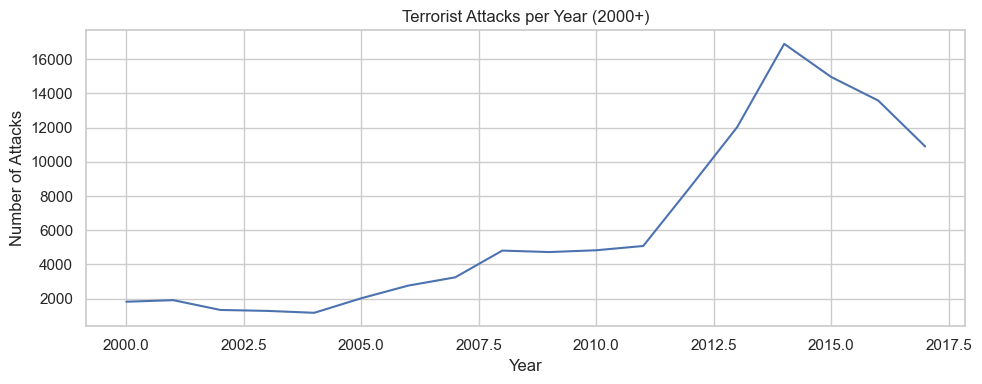

In [6]:
attacks_per_year = df["iyear"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
attacks_per_year.plot()
plt.title("Terrorist Attacks per Year (2000+)")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.tight_layout()
plt.show()


The number of recorded attacks increases sharply after 2010 and peaks in the mid-2010s. This suggests that the later portion of the dataset contains a period of especially intense terrorist activity, which makes temporal context useful in the clustering stage.


### Top Countries by Number of Attacks

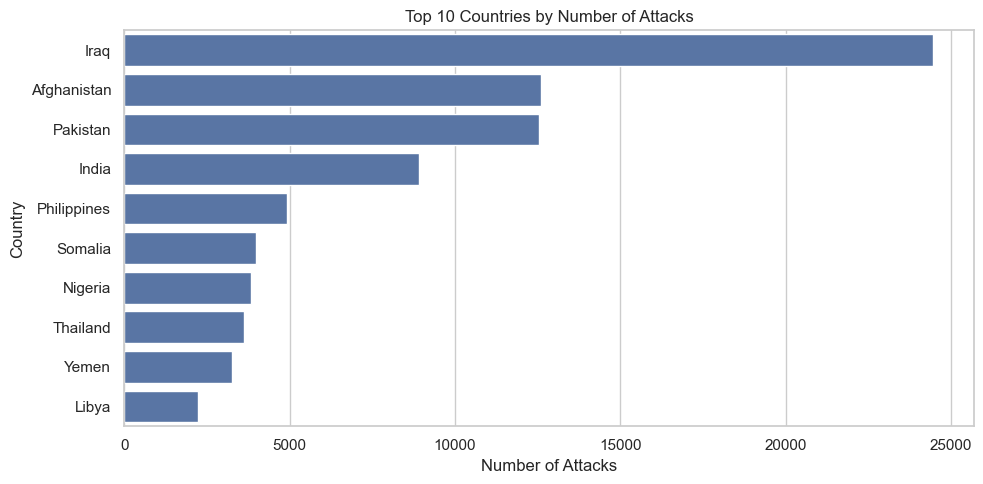

In [7]:
top_countries = df["country_txt"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries by Number of Attacks")
plt.xlabel("Number of Attacks")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


A relatively small number of countries account for a large share of attacks. This indicates that terrorism in the dataset is heavily concentrated in particular conflict zones rather than spread evenly across the world.


### Most Common Attack Types

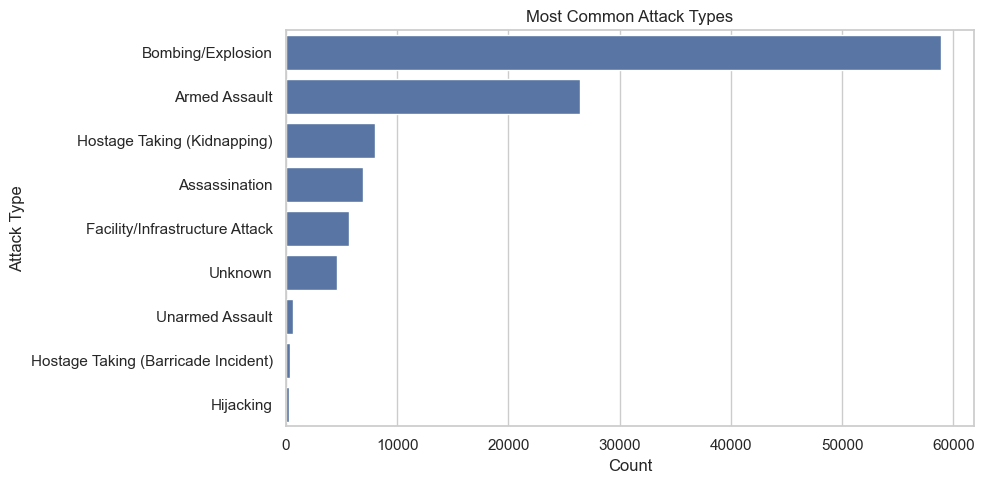

In [8]:
attack_types = df["attacktype1_txt"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=attack_types.values, y=attack_types.index)
plt.title("Most Common Attack Types")
plt.xlabel("Count")
plt.ylabel("Attack Type")
plt.tight_layout()
plt.show()


Bombings, armed assaults, and related attack forms dominate the data. This suggests that a few tactical patterns account for much of the activity in the modern GTD subset.


### Most Common Weapon Types

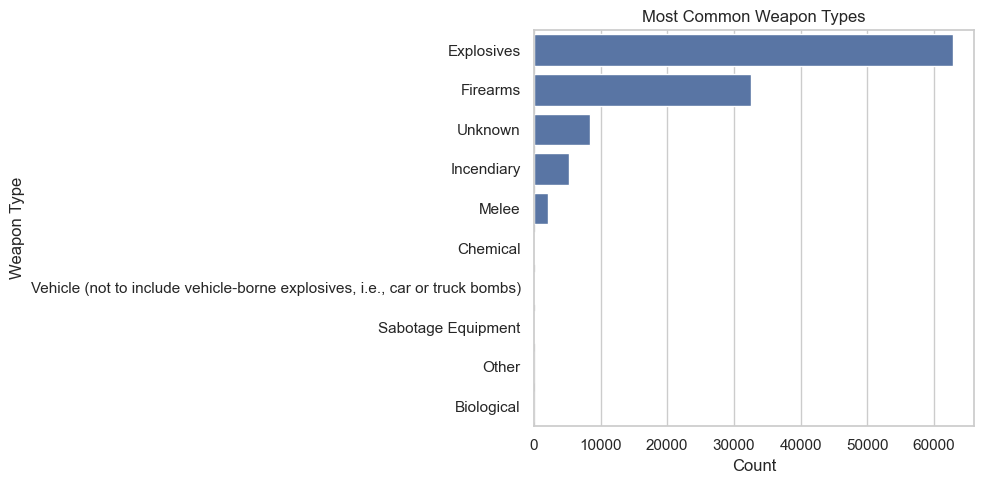

In [9]:
weapon_types = df["weaptype1_txt"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=weapon_types.values, y=weapon_types.index)
plt.title("Most Common Weapon Types")
plt.xlabel("Count")
plt.ylabel("Weapon Type")
plt.tight_layout()
plt.show()


Explosives and firearms appear most frequently, which aligns with the attack type distribution and suggests that these weapon categories will be important in distinguishing groups of incidents.


### Casualty Distribution

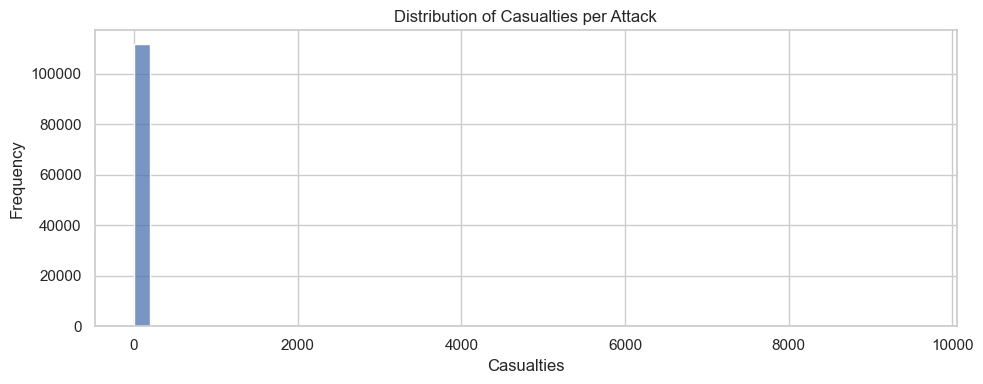

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(df["casualties"], bins=50)
plt.title("Distribution of Casualties per Attack")
plt.xlabel("Casualties")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Most incidents produce relatively few casualties, while a much smaller number cause very high harm. This distribution is strongly skewed, so using `log_casualties` is more appropriate than raw casualty counts for clustering.


### Casualties by Attack Type

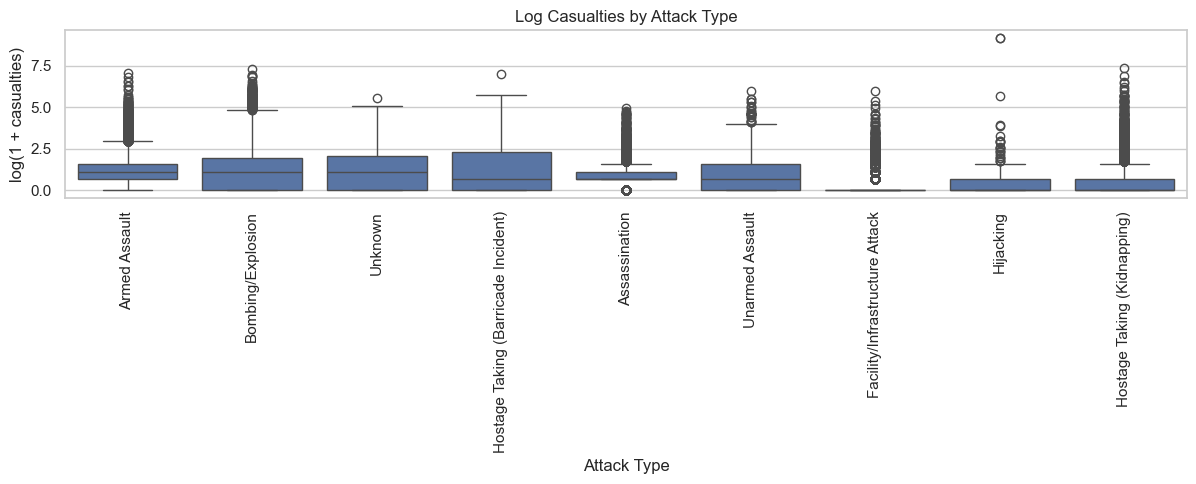

In [11]:
attack_order = df.groupby("attacktype1_txt")["casualties"].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 5))
sns.boxplot(x="attacktype1_txt", y="log_casualties", data=df, order=attack_order)
plt.xticks(rotation=90)
plt.title("Log Casualties by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("log(1 + casualties)")
plt.tight_layout()
plt.show()


Attack types differ in their typical severity. Some categories have consistently higher casualty ranges, which supports the idea that severity should be considered alongside categorical descriptors when identifying patterns.


## 7. Encode Features for Clustering

Categorical variables are represented with one-hot encoding so each category becomes its own feature. This lets the clustering algorithms work with category membership directly. The numerical features used here are `log_casualties` and `iyear`.


In [12]:
categorical_cols = ["attacktype1_txt", "targtype1_txt", "weaptype1_txt", "region_txt"]
numeric_cols = ["log_casualties", "iyear"]

df_encoded = pd.get_dummies(df[categorical_cols], prefix=categorical_cols)
feature_df = pd.concat([df_encoded, df[numeric_cols]], axis=1)

print("Encoded feature matrix shape:", feature_df.shape)
feature_df.head()


Encoded feature matrix shape: (111855, 57)


,attacktype1_txt_Armed Assault,attacktype1_txt_Assassination,attacktype1_txt_Bombing/Explosion,attacktype1_txt_Facility/Infrastructure Attack,attacktype1_txt_Hijacking,attacktype1_txt_Hostage Taking (Barricade Incident),attacktype1_txt_Hostage Taking (Kidnapping),attacktype1_txt_Unarmed Assault,attacktype1_txt_Unknown,targtype1_txt_Abortion Related,...,region_txt_Eastern Europe,region_txt_Middle East & North Africa,region_txt_North America,region_txt_South America,region_txt_South Asia,region_txt_Southeast Asia,region_txt_Sub-Saharan Africa,region_txt_Western Europe,log_casualties,iyear
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,2.079442,2000
1,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,2.079442,2000
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,1.386294,2000
3,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,0.693147,2000
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,2.833213,2000


## 8. Standardize Features

In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(feature_df)

print("Scaled feature matrix shape:", X.shape)


Scaled feature matrix shape: (111855, 57)


## 9. K-Means Model Selection

The number of clusters is evaluated with both the elbow method and silhouette scores. Because this is a large dataset with many categorical indicators, the metrics are computed on a reproducible random sample to keep runtime manageable.


In [14]:
sample_n = min(10000, len(df))
sample_positions = np.random.RandomState(0).choice(len(df), size=sample_n, replace=False)

X_sample = X[sample_positions]
print("Sample used for elbow and silhouette analysis:", X_sample.shape)


Sample used for elbow and silhouette analysis: (10000, 57)


### Elbow Method

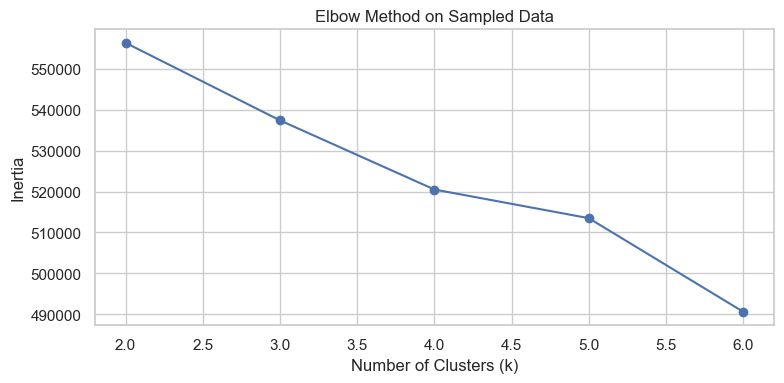

In [15]:
inertia = []
k_values = list(range(2, 7))

for k in k_values:
    model = KMeans(n_clusters=k, random_state=0, n_init=10)
    model.fit(X_sample)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method on Sampled Data")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()


### Silhouette Scores

In [16]:
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = model.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "k": k_values,
    "silhouette_score": silhouette_scores
})

silhouette_results


,k,silhouette_score
0,2,0.124055
1,3,0.115870
2,4,0.129741
3,5,0.132302
4,6,0.131290


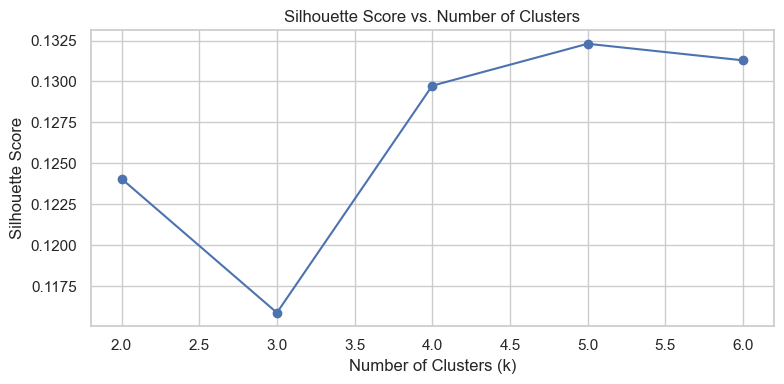

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


The elbow curve is gradual rather than sharply bent, so silhouette scores help clarify the choice of cluster count. The results support using **k = 3**, which provides a reasonable balance between separation and interpretability.


## 10. Final K-Means Clustering

In [18]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

df[["cluster"]].head()


,cluster
0,2
1,2
2,2
3,0
4,2


### Cluster Sizes

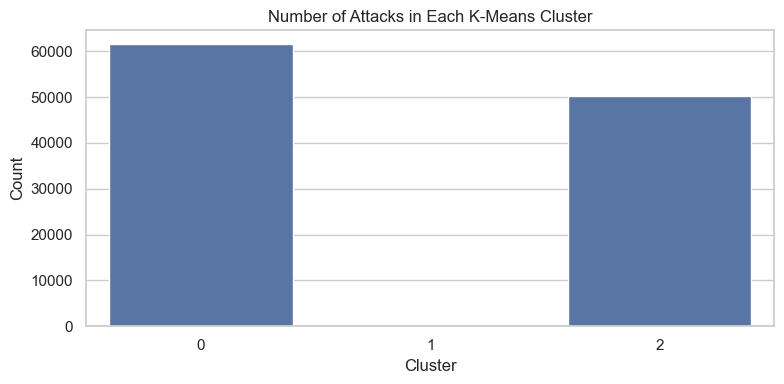

In [19]:
plt.figure(figsize=(8, 4))
sns.countplot(x="cluster", data=df)
plt.title("Number of Attacks in Each K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The cluster counts show how incidents are distributed across the three broad groups. This gives an immediate sense of whether the segmentation is balanced or dominated by one large cluster.


### Cluster Profile Summary

In [20]:
cluster_numeric_summary = df.groupby("cluster")[["casualties", "log_casualties", "iyear"]].agg(["mean", "median"])
cluster_numeric_summary


casualties        log_casualties                  iyear        
               mean median           mean    median         mean  median
cluster                                                                 
0          7.180829    2.0       1.204170  1.098612  2012.224585  2013.0
1        188.383178    3.0       1.529923  1.386294  2013.570093  2015.0
2          3.935062    1.0       0.945903  0.693147  2012.273105  2014.0

This summary table shows how the clusters differ in severity and time period. Differences in average or median casualty levels help distinguish lower-impact incidents from more severe ones, while year patterns indicate whether some clusters are associated with particular time periods.


### Most Common Categories by Cluster

In [21]:
def top_category_per_cluster(dataframe, cluster_col, category_col):
    result = (
        dataframe.groupby(cluster_col)[category_col]
        .agg(lambda x: x.value_counts().index[0])
        .rename(f"top_{category_col}")
    )
    return result

cluster_top_categories = pd.concat([
    top_category_per_cluster(df, "cluster", "attacktype1_txt"),
    top_category_per_cluster(df, "cluster", "targtype1_txt"),
    top_category_per_cluster(df, "cluster", "weaptype1_txt"),
    top_category_per_cluster(df, "cluster", "region_txt")
], axis=1)

cluster_top_categories


,top_attacktype1_txt,top_targtype1_txt,top_weaptype1_txt,top_region_txt
cluster,,,,
0,Bombing/Explosion,Private Citizens & Property,Explosives,Middle East & North Africa
1,Unarmed Assault,Military,Vehicle (not to include vehicle-borne explosiv...,Middle East & North Africa
2,Armed Assault,Private Citizens & Property,Firearms,South Asia


The most common categories in each cluster make the cluster patterns easier to interpret in domain terms. Instead of thinking only in terms of cluster numbers, this table highlights the attack types, targets, weapons, and regions that characterize each group most clearly.


## 11. PCA Visualization of K-Means Clusters

PCA reduces the high-dimensional feature space to two components for visualization. This does not replace the full clustering model; it simply provides a lower-dimensional view of how the incidents separate when all standardized features are considered together.


In [22]:
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X)

explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio (PC1, PC2):", explained_variance)
print("Total explained variance (2 PCs):", explained_variance.sum())


Explained variance ratio (PC1, PC2): [0.06129298 0.04078698]
Total explained variance (2 PCs): 0.10207996279599452


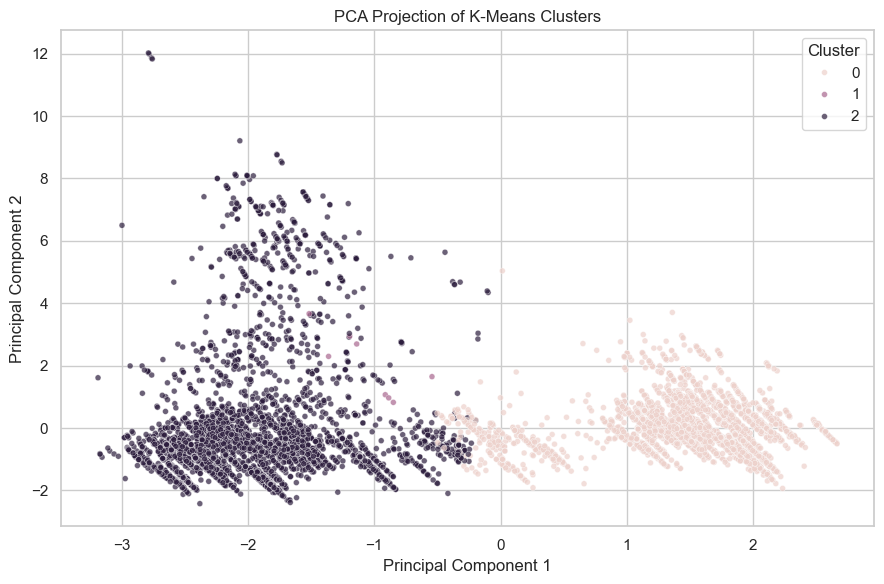

In [23]:
plot_n = min(12000, len(df))
plot_positions = np.random.RandomState(0).choice(len(df), size=plot_n, replace=False)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca[plot_positions, 0],
    y=X_pca[plot_positions, 1],
    hue=df.loc[plot_positions, "cluster"],
    s=18,
    alpha=0.7
)
plt.title("PCA Projection of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


The PCA plot provides a more meaningful picture of separation than plotting only one or two original variables. It helps show whether the three clusters occupy distinct regions in a lower-dimensional summary of the feature space.


## 12. DBSCAN as an Alternative Clustering Approach

DBSCAN is useful here because it does not require pre-specifying the number of clusters and can label unusual points as noise. Since density-based clustering can be computationally heavy in high dimensions, PCA is used first to reduce dimensionality before applying DBSCAN to a sample.


In [24]:
pca_db = PCA(n_components=10, random_state=0)
X_pca10 = pca_db.fit_transform(X)

dbscan_n = min(8000, len(df))
dbscan_positions = np.random.RandomState(0).choice(len(df), size=dbscan_n, replace=False)
X_db = X_pca10[dbscan_positions]

print("DBSCAN sample shape:", X_db.shape)
print("Variance captured by 10 PCs:", pca_db.explained_variance_ratio_.sum())


DBSCAN sample shape: (8000, 10)
Variance captured by 10 PCs: 0.3161555535011735


### Parameter Exploration for DBSCAN

In [25]:
dbscan_trials = []

for eps in [1.2, 1.5, 1.8]:
    for min_samples in [10, 20]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_db)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = (labels == -1).mean() * 100
        dbscan_trials.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters_found": n_clusters,
            "noise_percent": round(noise_pct, 2)
        })

pd.DataFrame(dbscan_trials)


,eps,min_samples,clusters_found,noise_percent
0,1.2,10,93,17.34
1,1.2,20,62,24.62
2,1.5,10,53,12.49
3,1.5,20,36,18.39
4,1.8,10,18,7.48
5,1.8,20,10,10.98


This parameter table shows how sensitive DBSCAN is to `eps` and `min_samples`. Rather than looking for a single perfect setting, the goal is to understand whether DBSCAN finds dense groups, produces mostly noise, or breaks the data into many small components.


In [26]:
dbscan = DBSCAN(eps=1.5, min_samples=20)
db_labels = dbscan.fit_predict(X_db)

dbscan_results = pd.DataFrame({
    "pc1": X_db[:, 0],
    "pc2": X_db[:, 1],
    "db_cluster": db_labels
})

dbscan_results["db_cluster"].value_counts().sort_index()


db_cluster
-1     1471
 0     4193
 1       68
 2      722
 3       91
 4       28
 5       80
 6      124
 7       48
 8       23
 9      266
 10      46
 11      35
 12      45
 13      43
 14      21
 15      42
 16      27
 17      26
 18      45
 19      40
 20      23
 21      59
 22      57
 23      21
 24      38
 25      45
 26      41
 27      34
 28      28
 29      20
 30      45
 31      24
 32      20
 33      21
 34      29
 35      11
Name: count, dtype: int64

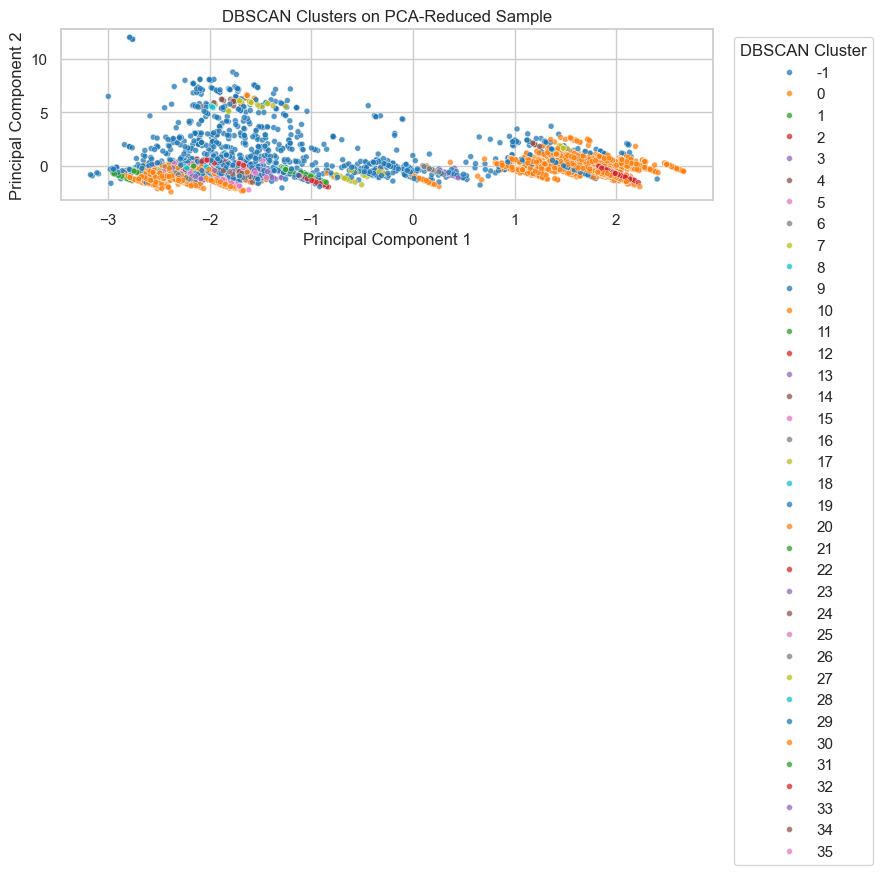

In [27]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=dbscan_results,
    x="pc1",
    y="pc2",
    hue="db_cluster",
    palette="tab10",
    s=18,
    alpha=0.75
)
plt.title("DBSCAN Clusters on PCA-Reduced Sample")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="DBSCAN Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


DBSCAN provides a different view of the data than K-Means. It can identify dense pockets of similar incidents while also labeling observations that do not fit well into any dense region. Those noise points are useful because they highlight less typical or more unusual attack patterns.


## 13. Decision Tree for Cluster Interpretation

A decision tree is used here as an interpretability tool rather than as a pure prediction model. By treating the K-Means cluster labels as classes, the tree shows which features are most useful for distinguishing clusters and turns those differences into readable rules.


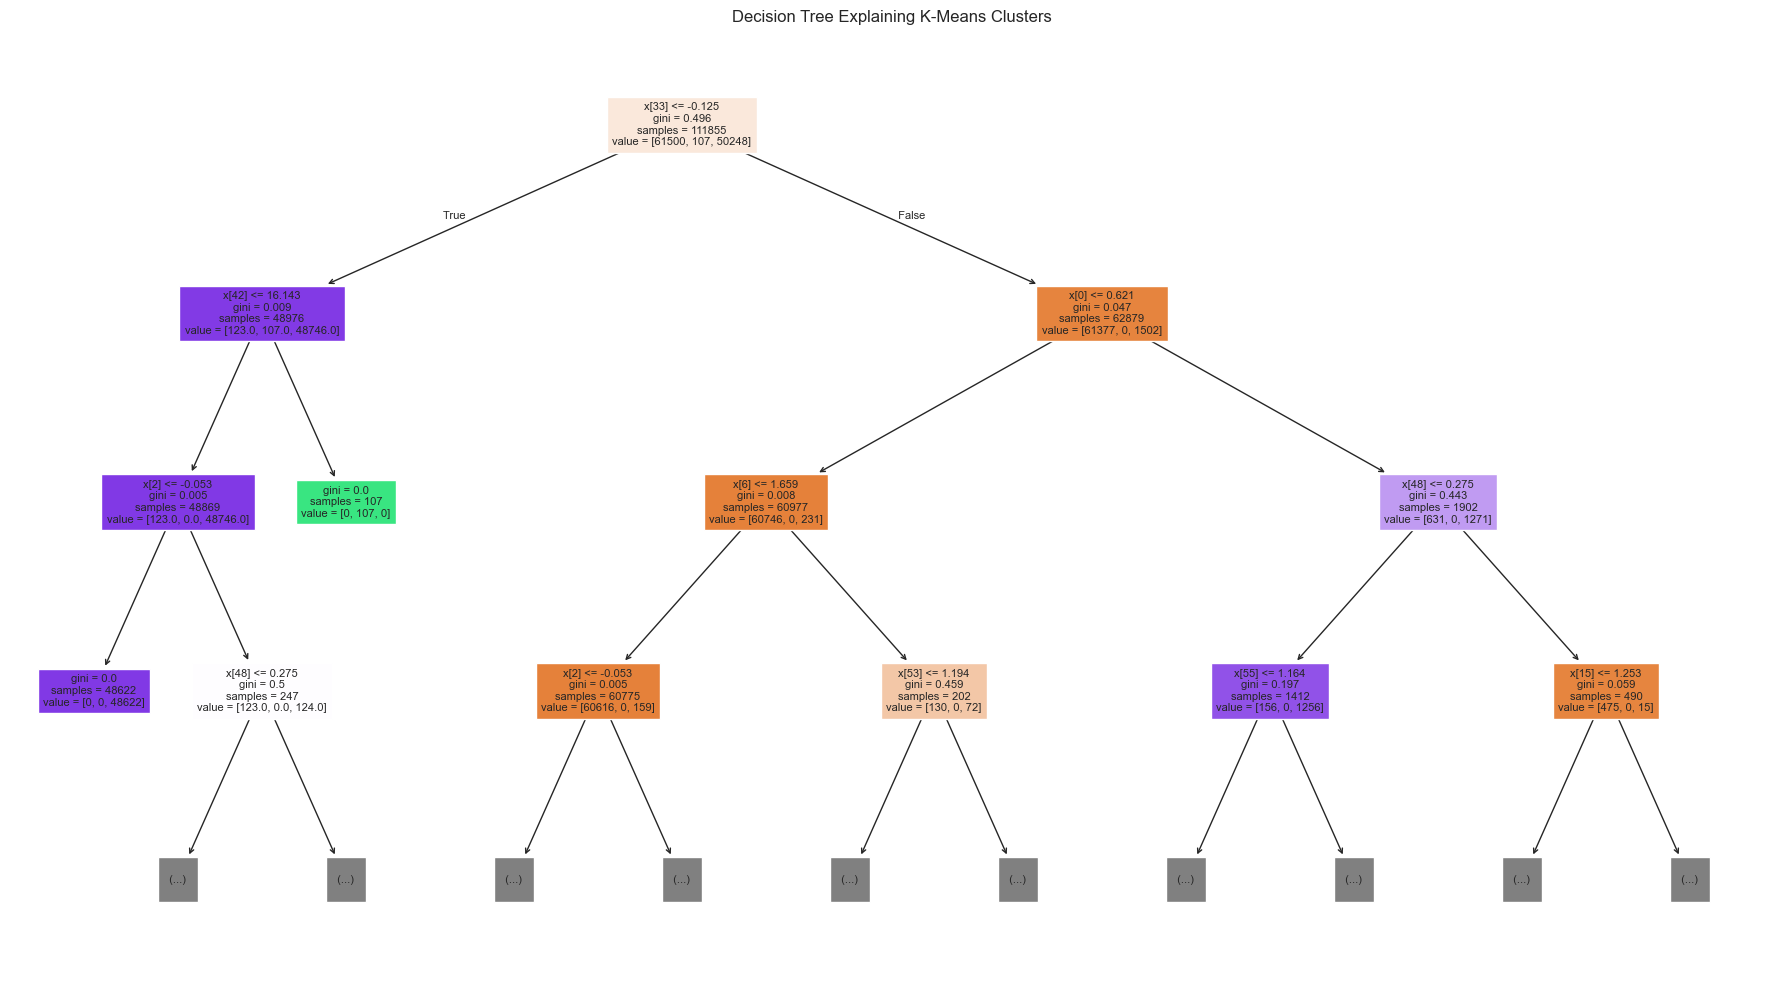

In [28]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=0)
tree_model.fit(X, df["cluster"])

plt.figure(figsize=(18, 10))
plot_tree(
    tree_model,
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree Explaining K-Means Clusters")
plt.tight_layout()
plt.show()


The first few splits in the decision tree highlight the features that most strongly separate the clusters. This makes the cluster structure easier to explain because it shows which combinations of severity, weapon categories, attack types, or contextual variables are most associated with each group.


## 14. Comparing K-Means and DBSCAN

The two clustering methods answer slightly different questions. K-Means is useful for broad segmentation across the full dataset, while DBSCAN is more useful for finding dense local structure and identifying noise points. Using both methods gives a fuller picture of the data than either one alone.


## 15. Discovery Question Progress

### Discovery Question 1: Are there natural clusters of terrorist incidents based on attack characteristics?

Yes. K-Means suggests that the incidents can be partitioned into three broad groups when attack type, target type, weapon type, severity, region, and year are considered together.

### Discovery Question 2: How do geographic and temporal context affect the clustering structure?

Region and year contribute useful context because attacks are not defined only by tactics. The concentration of incidents in specific regions and the strong variation over time suggest that clustering improves when those dimensions are included.

### Discovery Question 3: What additional structure appears when a density-based clustering method is used?

DBSCAN reveals that some incidents behave like members of dense local groups, while others appear as noise. This suggests that the dataset contains both common recurring patterns and more unusual event types that do not fit neatly into broad centroid-based segments.


## 16. Final Interpretation

The analysis shows that modern terrorist incidents are not a single homogeneous type of event. Instead, they can be organized into meaningful patterns that differ in severity, tactics, weapons, targets, time period, and regional context.

K-Means provides a clear high-level segmentation of the incidents, while DBSCAN offers a complementary perspective by emphasizing dense subgroups and irregular observations. PCA helps visualize these relationships in a reduced space, and the decision tree makes the K-Means structure easier to interpret with readable rules.

Taken together, these methods support the conclusion that terrorist incidents in the GTD form multiple distinct patterns rather than one uniform population.


## 17. M4 Plan

For M4, the technical work is largely complete. The remaining tasks are to refine cluster names, strengthen the limitations discussion, improve presentation quality, and sharpen the written interpretation so the final story is clearer and more polished.
